# Utnyttjandemodell för revolverande kreditlinor till småföretag


## Sammanfattning för ledningen

Revolverande kreditlinor är beviljade men inte fullt utnyttjade, så en långivares **finansierade saldo** — och det ekonomiska kapital som måste hållas mot det — beror på hur mycket av varje lina som låntagaren faktiskt använder. Denna analys modellerar **utnyttjandegraden** (utnyttjat saldo / beviljad gräns) för ett arbetsurval om **100 revolverande linor till småföretag** för att prognostisera finansierad exponering och stödja kapitalplaneringen.

Vi kombinerar fyra SAS-procedurer, som var och en besvarar en distinkt planeringsfråga:

- **PROC MEANS** profilerar utnyttjat saldo och utnyttjande efter intern **riskklass**. Det genomsnittliga utnyttjandet stiger monotont över klasserna — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E) — och etablerar det empiriska sambandet mellan kreditkvalitet och användning som ligger till grund för antaganden om exponering vid fallissemang.
- **PROC REG** anpassar utnyttjande mot låntagarens fundamenta (räntetäckningsgrad, intäktsvolatilitet, linans mognad, tidigare utnyttjande) och den makroekonomiska miljön (arbetslöshet, korträntan). Modellen förklarar 45 % av variansen (R-Square 0.448, F p < .0001), och de standardiserade skattningarna rangordnar **räntetäckningsgrad** (-0.45) och **tidigare utnyttjande** (0.41) som de dominerande drivkrafterna. Alla varianceinflationsfaktorer håller sig under 1.17, så kollinearitet är inte ett problem.
- **PROC GLM** testar om utnyttjandet skiljer sig åt mellan **branschsegment** efter att man kontrollerat för dessa drivkrafter, med Tukey-justerade minsta-kvadrat-medelvärden. Brancheffekten är gränsfall totalt sett (F p = 0.060), men **Bygg** utnyttjar signifikant mer än **Detaljhandel** (p = 0.007) och **Hälsovård** (p = 0.024) när låntagarens kvalitet hålls konstant.
- **PROC UNIVARIATE** extraherar utnyttjandets 2,5:e och 97,5:e percentiler — ett band från **0.121 till 0.744** kring ett medelvärde på 0.404 — som definierar det rimliga scenariot för lågt/högt utnyttjande vid stress- och ekonomiskt kapitaltestning.

Tillsammans låter dessa resultat banken översätta en statisk bok av beviljade gränser till en **framåtblickande prognos av finansierat saldo** med försvarbara, granskningsbara antaganden. Urvalet om 100 linor är den del som denna miljö kör; samma program skalar oförändrat till en fullständig produktionsbok.


## Datakällor

Datamängden genereras syntetiskt inuti notebooken (inga externa filer, inget nätverk). Varje rad är en revolverande kreditlina till ett småföretag observerad vid en tidpunkt.

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `lina_id` | Num | Unik identifierare för kreditlinan |
| `riskklass` | Char | Intern riskklass (A bäst … E svagast) |
| `bransch` | Char | Låntagarens branschsegment (Detaljhandel, Tjänster, Bygg, Tillverkning, Hälsovård) |
| `beviljad_grans` | Num | Beviljat kreditlinebelopp ($000-tal) |
| `manader_pa_bok` | Num | Linans mognad (månader sedan uppläggning) |
| `rantetackningsgrad` | Num | Räntetäckningsgrad |
| `intaktsvolatilitet` | Num | Efterföljande intäktsvolatilitet (variationskoefficient) |
| `tidigare_utnyttjande` | Num | Utnyttjandegrad under föregående period (0–1) |
| `arbetsloshet` | Num | Lokal arbetslöshet (%) vid observationsdatumet |
| `kortranta` | Num | Rådande kortsiktig referensränta (%) |
| `utnyttjandegrad` | Num | Utnyttjat saldo / beviljad gräns (0–1), den modellerade responsen |
| `utnyttjat_saldo` | Num | Finansierat saldo = utnyttjandegrad × beviljad_grans ($000-tal) |

**Skala:** DATA-steget är skrivet för att generera en fullständig bok, men denna miljö körs olicensierad och begränsar utdata till de första **100 linorna** — arbetsurvalet som analyseras genomgående. Dessa 100 linor spänner över alla 5 riskklasserna (A–E) och alla 5 branschsegment. Utnyttjandet simuleras från en logit-länkad latent variabel som drivs av kovariaterna ovan plus brus, så regressionen och GLM återfinner genuin, tolkningsbar signal. Körtiden är väl under 60 sekunder.


## 1. Generera den syntetiska kreditlineportföljen

Den första cellen bygger en realistisk bok av revolverande linor till småföretag (denna miljö begränsar körningen till de första **100 linorna**). Vi drar en riskklass och ett branschsegment för varje lina och simulerar sedan låntagarens fundamenta och den makroekonomiska miljön. Utnyttjandet genereras från ett **logit-länkat latent poäng** så att svagare klasser, lägre räntetäckningsgrad, högre intäktsvolatilitet, mer trögrörligt tidigare utnyttjande och en pressad makrobakgrund alla driver upp den utnyttjade andelen — precis den struktur som regressionen och GLM nedan är avsedda att återfinna. Det finansierade `utnyttjat_saldo` är sedan utnyttjandet gånger den beviljade gränsen.


In [1]:
/* --------------------------------------------------------
   Generera en syntetisk portfölj av revolverande
   kreditlinor till småföretag. Utnyttjandet simuleras från
   en logit-länkad latent variabel som drivs av kredit-,
   låntagar- och makrokovariater, så att modellerna nedan
   återfinner genuin signal.
   -------------------------------------------------------- */
data kreditlinor;
    CALL streaminit(20260605);

    ETIKETT lina_id             = "Identifierare för kreditlina"
          riskklass           = "Intern riskklass (A-E)"
          bransch             = "Låntagarens branschsegment"
          beviljad_grans      = "Beviljad gräns (000-tal $)"
          manader_pa_bok      = "Linans mognad (månader)"
          rantetackningsgrad  = "Räntetäckningsgrad"
          intaktsvolatilitet  = "Intäktsvolatilitet (VK)"
          tidigare_utnyttjande = "Utnyttjandegrad föregående period"
          arbetsloshet        = "Lokal arbetslöshet (%)"
          kortranta           = "Kort referensränta (%)"
          utnyttjandegrad     = "Utnyttjandegrad (utnyttjat/gräns)"
          utnyttjat_saldo     = "Finansierat saldo (000-tal $)";

    /* Uppslagsarrayer för kategoriska attribut */
    FÄLT klasser[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    FÄLT segment[5] $13 _temporary_
        ('Detaljhandel' 'Tjänster' 'Bygg'
         'Tillverkning' 'Hälsovård');

    GÖR lina_id = 1 TILL 4000;

        /* Riskklass: mer massa i mittklasserna */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        riskklass = klasser[g];

        /* Branschsegment: ungefär jämnt med övervikt för detaljhandel */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        bransch = segment[s];

        /* Beviljad gräns: log-normal, 25k$ till ~1,5M$ */
        beviljad_grans = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Låntagarens fundamenta */
        manader_pa_bok = round(rand('UNIFORM') * 84 + 3, 1);
        rantetackningsgrad = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        intaktsvolatilitet = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        tidigare_utnyttjande = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Makroekonomisk miljö vid observationsdatumet */
        arbetsloshet = round(rand('NORMAL', 5.2, 1.1), 0.1);
        OM arbetsloshet < 2.5 SÅ arbetsloshet = 2.5;
        kortranta = round(rand('NORMAL', 4.0, 0.8), 0.01);
        OM kortranta < 0 SÅ kortranta = 0;

        /* Klassens svårighetsindex: A=0 ... E=4 */
        klass_svarighet = g - 1;

        /* Logit-länkad latent utnyttjandepoäng.
           Svagare klasser, lägre räntetäckning, högre
           volatilitet, trögt tidigare utnyttjande och
           makrostress höjer användningen. */
        eta = -0.60
              + 0.34 * klass_svarighet
              - 0.55 * (rantetackningsgrad - 1.4)
              + 1.10 * (intaktsvolatilitet - 0.24)
              + 1.80 * (tidigare_utnyttjande - 0.45)
              + 0.16 * (arbetsloshet - 5.2)
              + 0.07 * (kortranta - 4.0)
              - 0.004 * (manader_pa_bok - 40);

        /* Branschsegmentets skift på den latenta skalan */
        VÄLJ (bransch);
            NÄR ('Bygg')         eta = eta + 0.30;
            NÄR ('Detaljhandel') eta = eta + 0.12;
            NÄR ('Tillverkning') eta = eta - 0.08;
            NÄR ('Hälsovård')    eta = eta - 0.22;
            ANNARS_OM; /* Tjänster = referens */
        SLUT;

        /* Lägg till brus, mappa till (0,1) via logistisk länk */
        eta = eta + rand('NORMAL', 0, 0.45);
        utnyttjandegrad = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Finansierat saldo följer av utnyttjandet */
        utnyttjat_saldo = round(utnyttjandegrad * beviljad_grans,
                              0.1);

        UTDATA;
    SLUT;

    BEHÅLL lina_id riskklass bransch beviljad_grans
         manader_pa_bok rantetackningsgrad intaktsvolatilitet
         tidigare_utnyttjande arbetsloshet kortranta
         utnyttjandegrad utnyttjat_saldo;
KÖR;



NOTE: DATA kreditlinor

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote kreditlinor (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.49 seconds
  cpu   1.49 seconds


## 2. Finansierad exponering efter riskklass

Ekonomiska kapitalmodeller behöver veta hur finansierat saldo och utnyttjande varierar mellan kreditkvaliteter. **PROC MEANS** sammanfattar utnyttjat saldo och utnyttjande för varje intern riskklass med hela den distributionella bilden — medelvärde, standardavvikelse, kvartiler och spännvidd. Vi förväntar oss att utnyttjandet stiger monotont från klass A till klass E, vilket direkt ligger till grund för antaganden om exponering vid fallissemang för den revolverande boken.


In [2]:
/* Utnyttjat saldo och utnyttjande efter intern riskklass */
PROCEDUR MEDELVÄRDEN data=kreditlinor NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    KLASS riskklass;
    VARIABEL utnyttjat_saldo utnyttjandegrad beviljad_grans;
KÖR;


                                                  The MEANS Procedure

                           Analysis Variable : utnyttjat_saldo Finansierat saldo (000-tal $)

        Intern riskklass (A-E)          N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        ------------------------------------------------------------------------------------------------------------------------------------------------
        A                                  18         41.878         24.140          7.700          28.400         37.200          54.400        103.300
        B                                  26         43.565         24.701          7.800          25.700         34.550          59.500         99.900
        C                                  29         56.793         52.653         13.300          33.500         45.600          57.000        300.100
        D                                  18         78.139         4


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Drivkrafter för utnyttjande — multipel regression

**PROC REG** modellerar utnyttjandegraden mot låntagarens fundamenta och den makroekonomiska miljön. Vi begär:

- **CLB** — 95 %-iga konfidensgränser för varje koefficient, så att kreditteamet kan rapportera effektintervall i stället för punktskattningar.
- **VIF** och **TOL** — varianceinflationsfaktorer och tolerans för att bekräfta att kovariaterna inte är kollineära.
- **STB** — standardiserade skattningar för att rangordna drivkrafter på en jämförbar skala.

Koefficienterna besvarar planeringsfrågan direkt: hur mycket ändrar en enhetsförändring i varje drivkraft den förväntade utnyttjade andelen av en lina? Den anpassade modellen förklarar 45 % av utnyttjandevariansen (R-Square 0.448, total F p < .0001). PROC REG genererar även sin ODS-standardpanel med diagnostik — residualer mot predikterade, ett residualhistogram, residualer mot observationsordning, en normal Q-Q-plot och en Cook's D-inflytandeplot — som visas under tabellen. Proceduren är en interaktiv RUN-gruppsprocedur, så vi stänger den med `quit;` för att tömma utdata.


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                         Dependent Variable: utnyttjandegrad Utnyttjandegrad (utnyttjat/gräns)                         

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.32245      0.22041     12.36    <.0001
Error                  93         1.65829      0.01783                    
Corrected Total        99         2.98074                                 

Root MSE           0.13353    R-Square            0.4437
Dependent Mean       0.41030    Adj R-Sq            0.4078
Coeff Var         32.54523

                                                                                                 Parameter Estimates 


NOTE: PROC REG data=kreditlinor

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


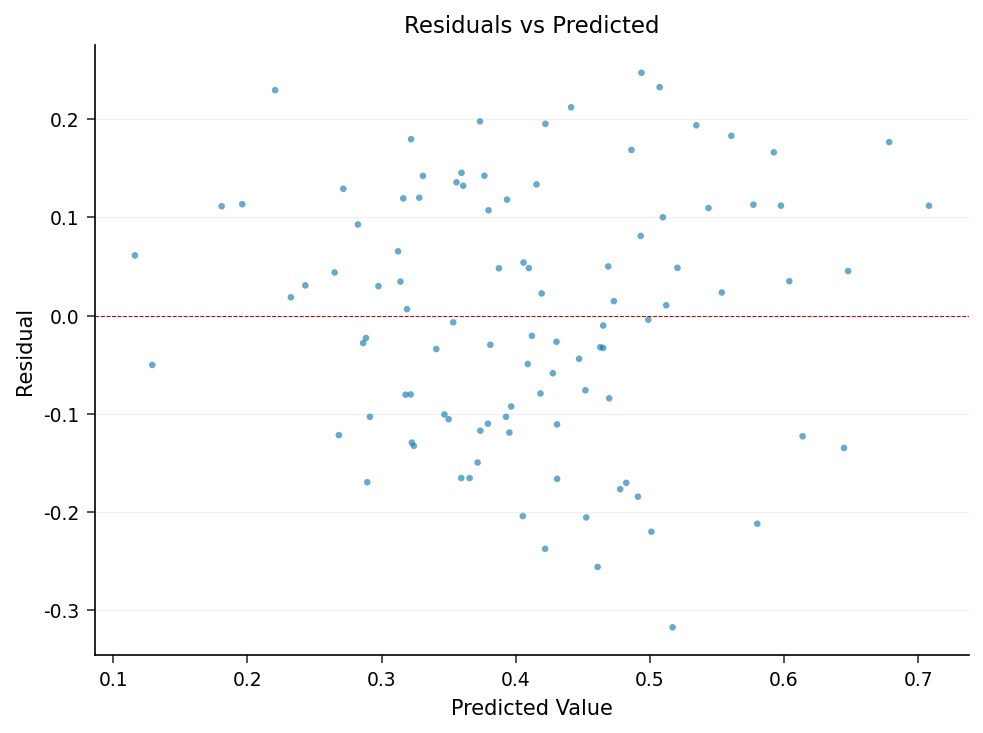

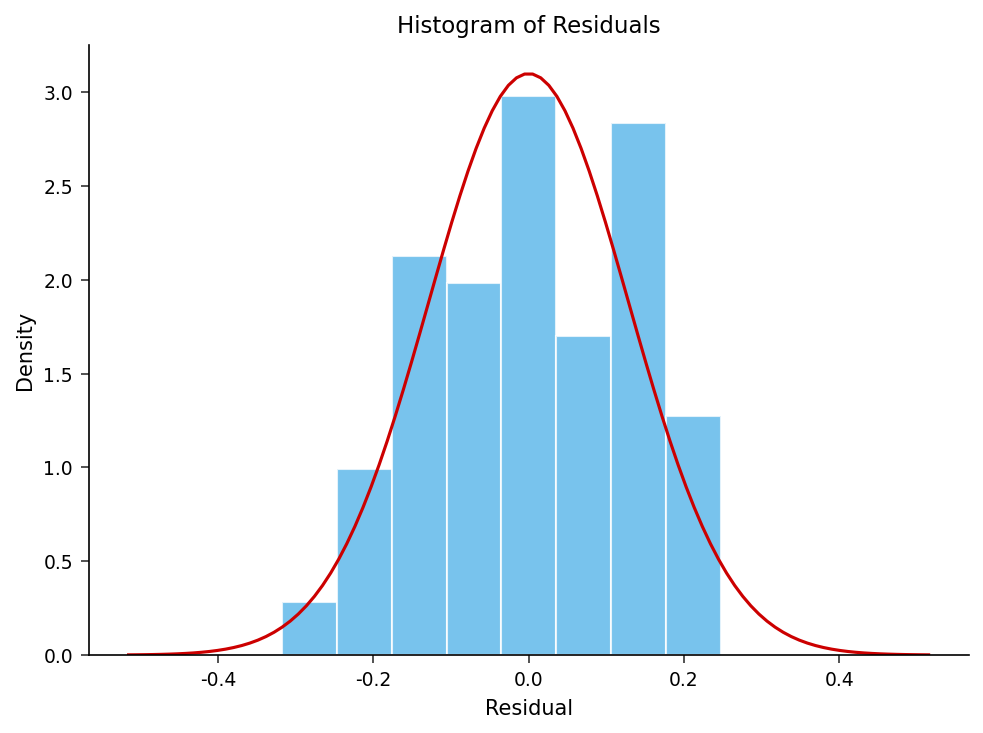

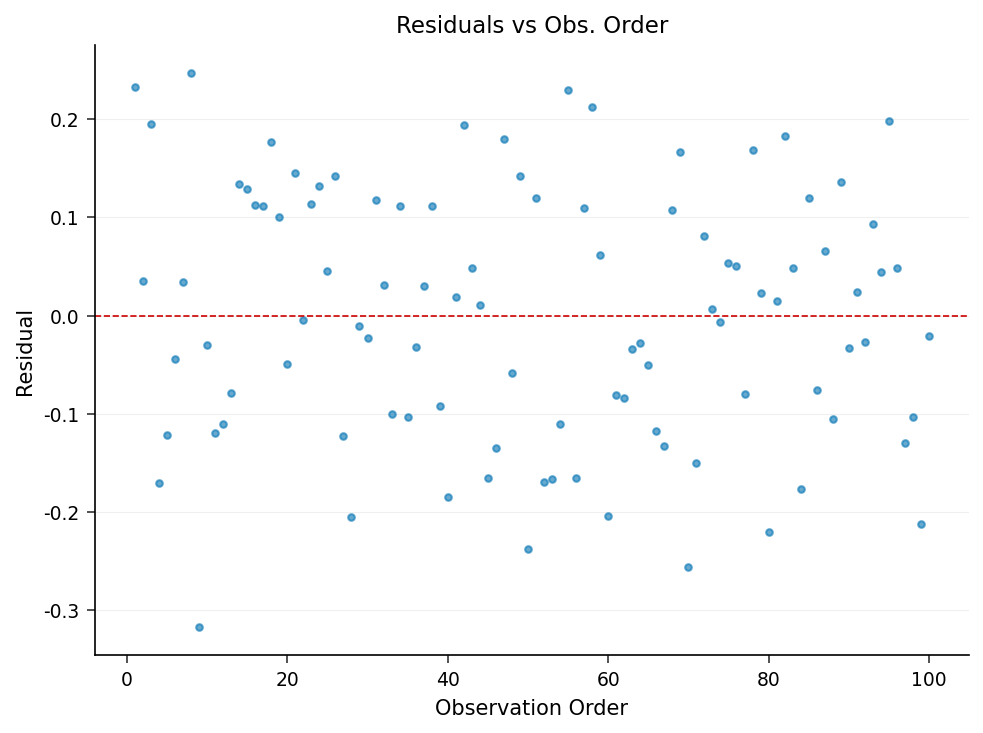

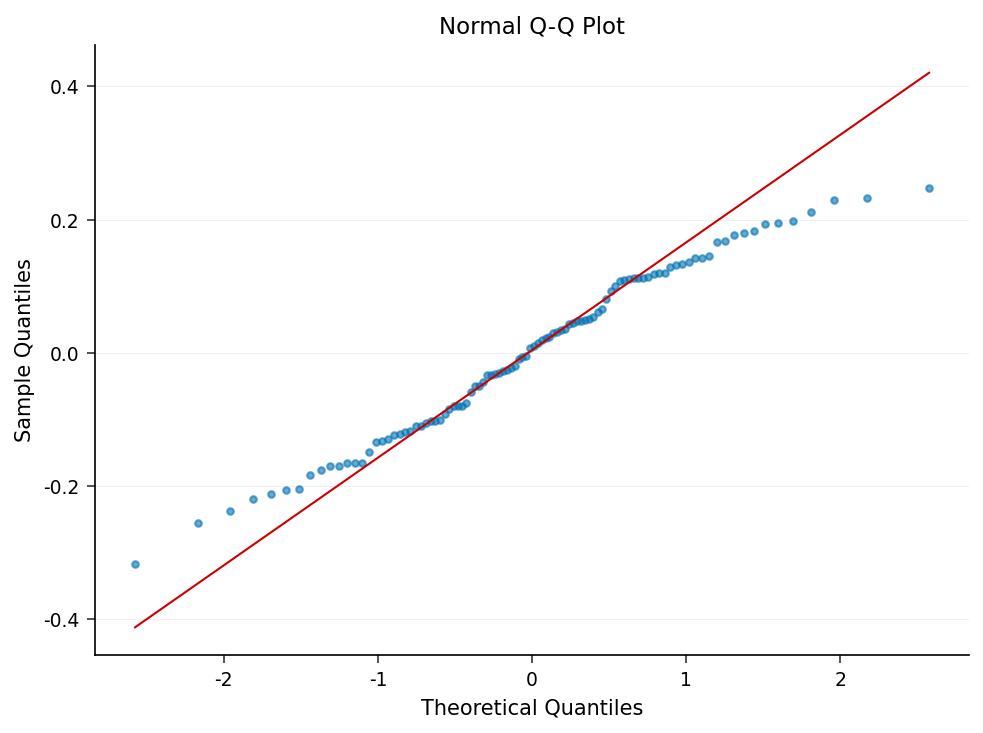

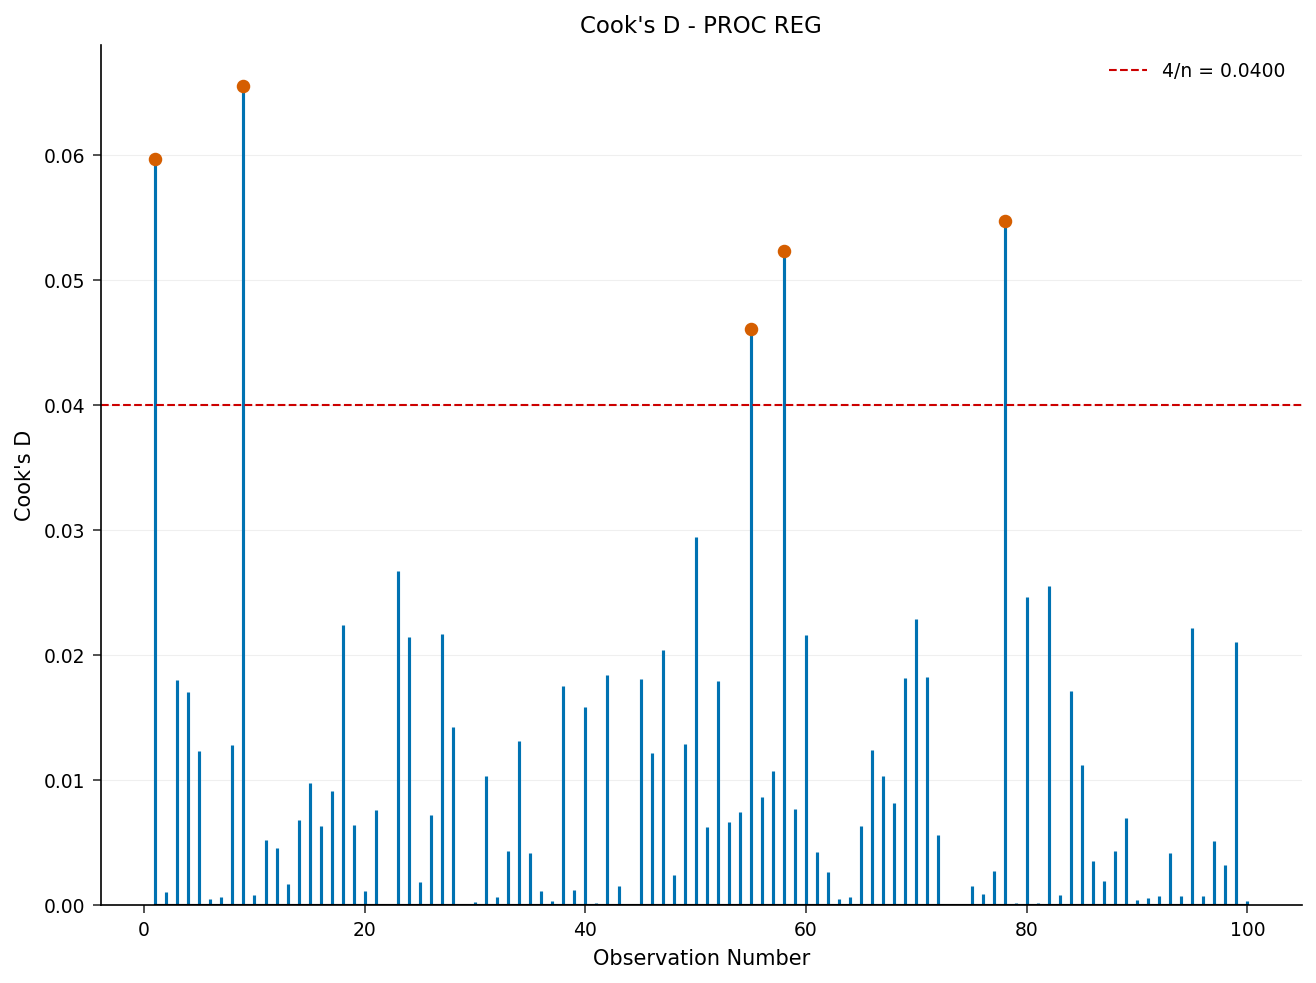

In [3]:
/* Utnyttjandegrad mot låntagar- och makrokovariater */
PROCEDUR REG data=kreditlinor;
    MODEL utnyttjandegrad =
          rantetackningsgrad intaktsvolatilitet tidigare_utnyttjande
          manader_pa_bok arbetsloshet kortranta
          / clb stb vif tol;
KÖR;
QUIT;


## 4. Utnyttjande efter branschsegment — generell linjär modell

Utnyttjar vissa branscher sina linor mer aggressivt när vi väl tar hänsyn till låntagarens kvalitet och makrobakgrunden? **PROC GLM** behandlar `bransch` som en klassificeringseffekt och lägger till samma kontinuerliga kovariater som kontroller i kovariansanalysen. Vi begär:

- **SOLUTION** — parameterskattningarna för varje branschnivå relativt referensen.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — Tukey-justerade minsta-kvadrat-medelvärden och parvisa skillnader, det kovariatjusterade utnyttjandet för varje segment.

GLM genererar samma ODS-diagnostikpanel som REG plus ett stapeldiagram över minsta-kvadrat-medelvärden per bransch (med konfidensintervall), som visas under tabellerna. Den är också en RUN-gruppsprocedur, så den avslutas med `quit;`.


                               The GLM Procedure                               
    Dependent Variable: utnyttjandegrad Utnyttjandegrad (utnyttjat/gräns)     

Source                      DF  Sum of Squares  Mean Square   F Value    Pr > F
--------------------  --------  --------------  -----------  --------  --------
bransch                      4         0.14353      0.03588      2.09    0.0880
rantetackningsgrad           1         0.69230      0.69230     40.42    <.0001
intaktsvolatilitet           1         0.13227      0.13227      7.72    0.0066
tidigare_utnyttjande         1         0.42071      0.42071     24.56    <.0001
arbetsloshet                 1         0.14213      0.14213      8.30    0.0050
kortranta                    1         0.09328      0.09328      5.45    0.0218
Error                       90         1.54156      0.01713                    

Root MSE           0.13088    R-Square            0.4828
Adj R-Sq            0.4311

                           Paramet


NOTE: PROC GLM data=kreditlinor

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_bransch.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


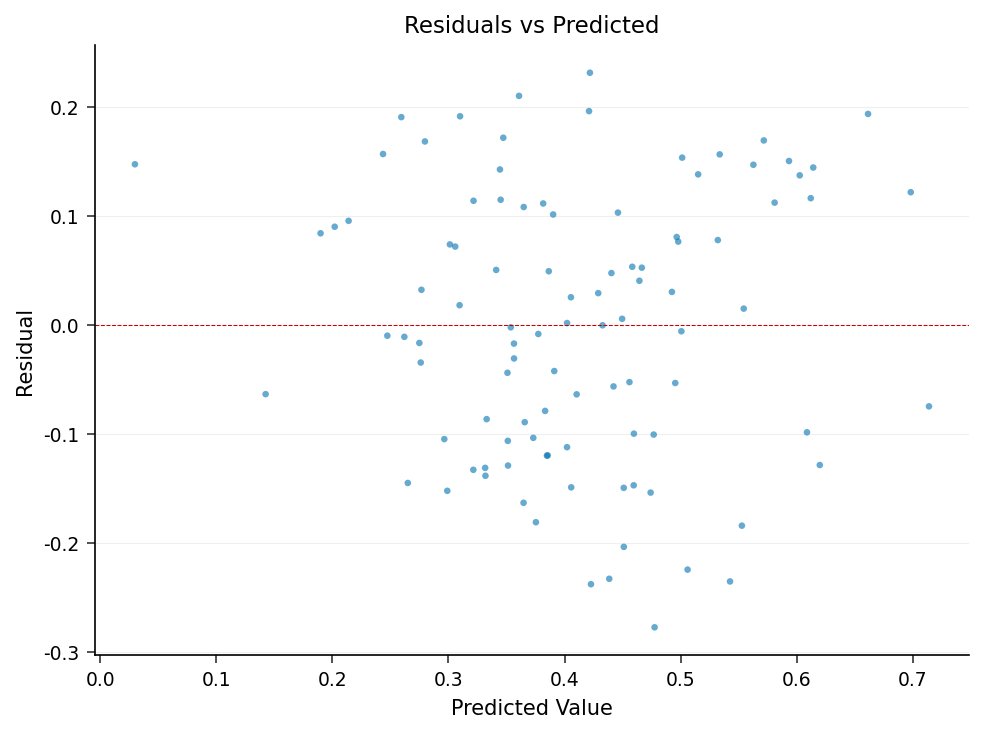

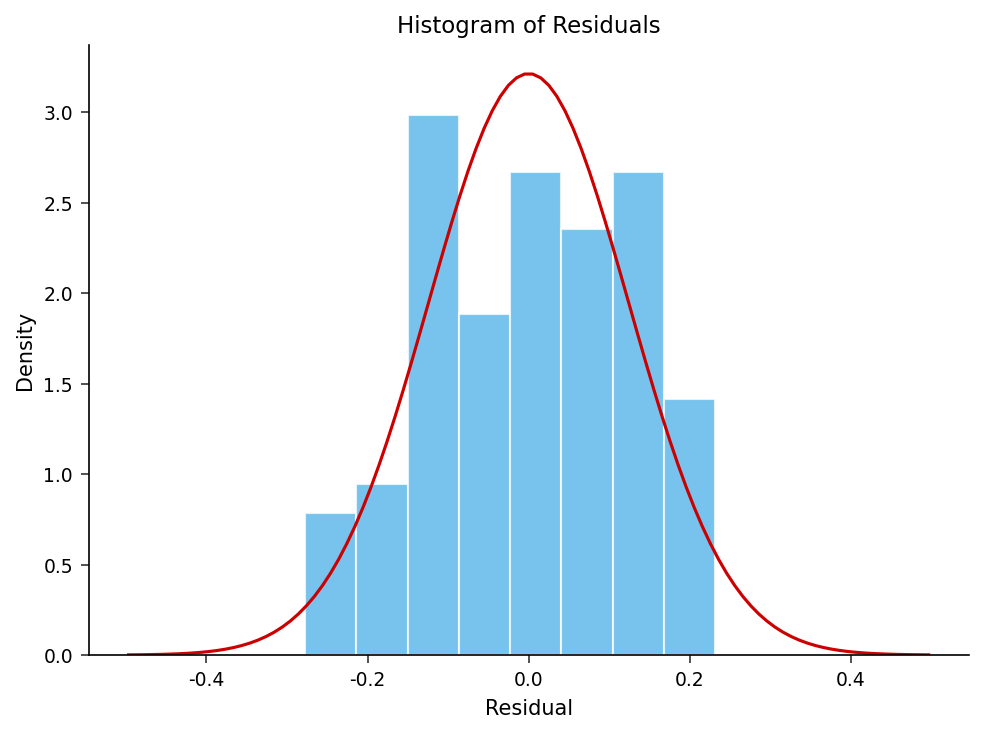

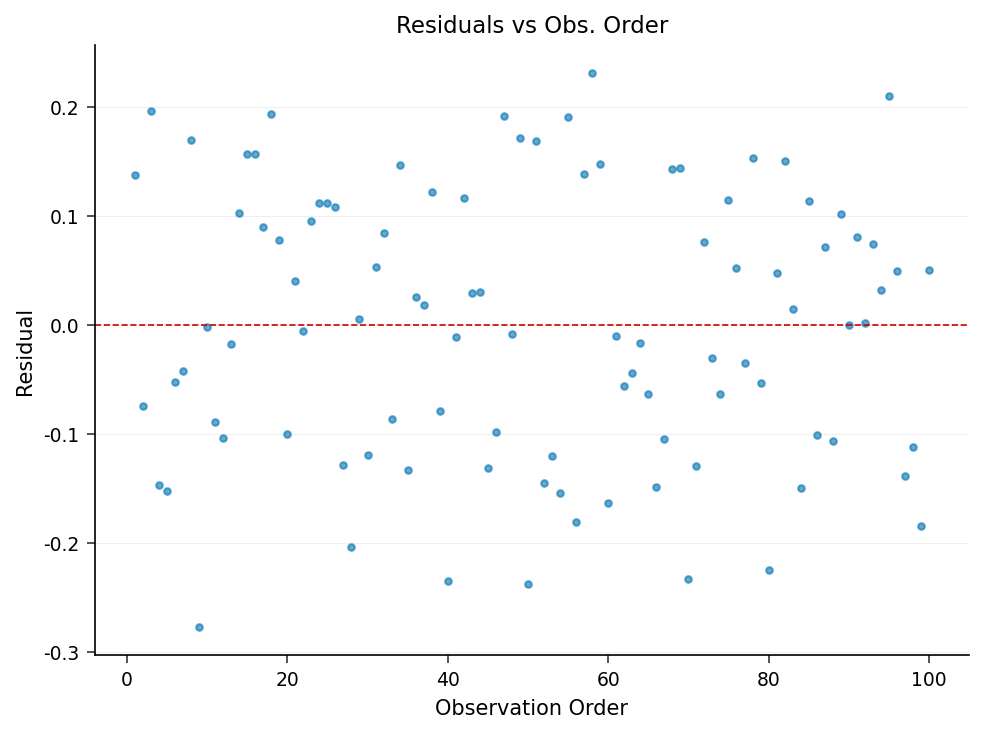

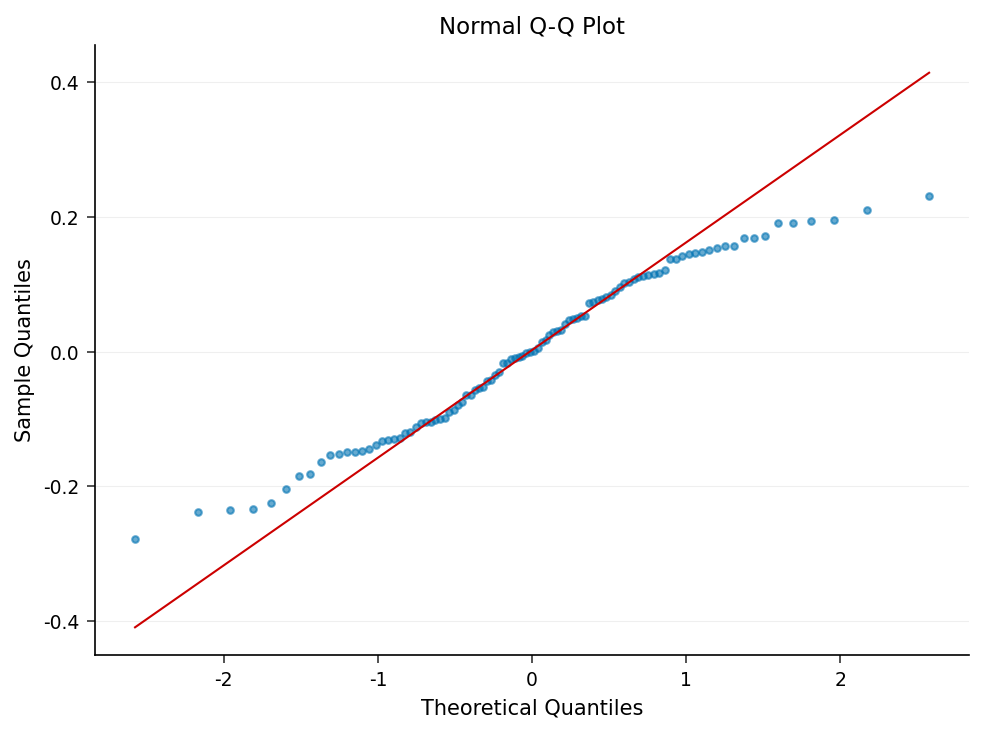

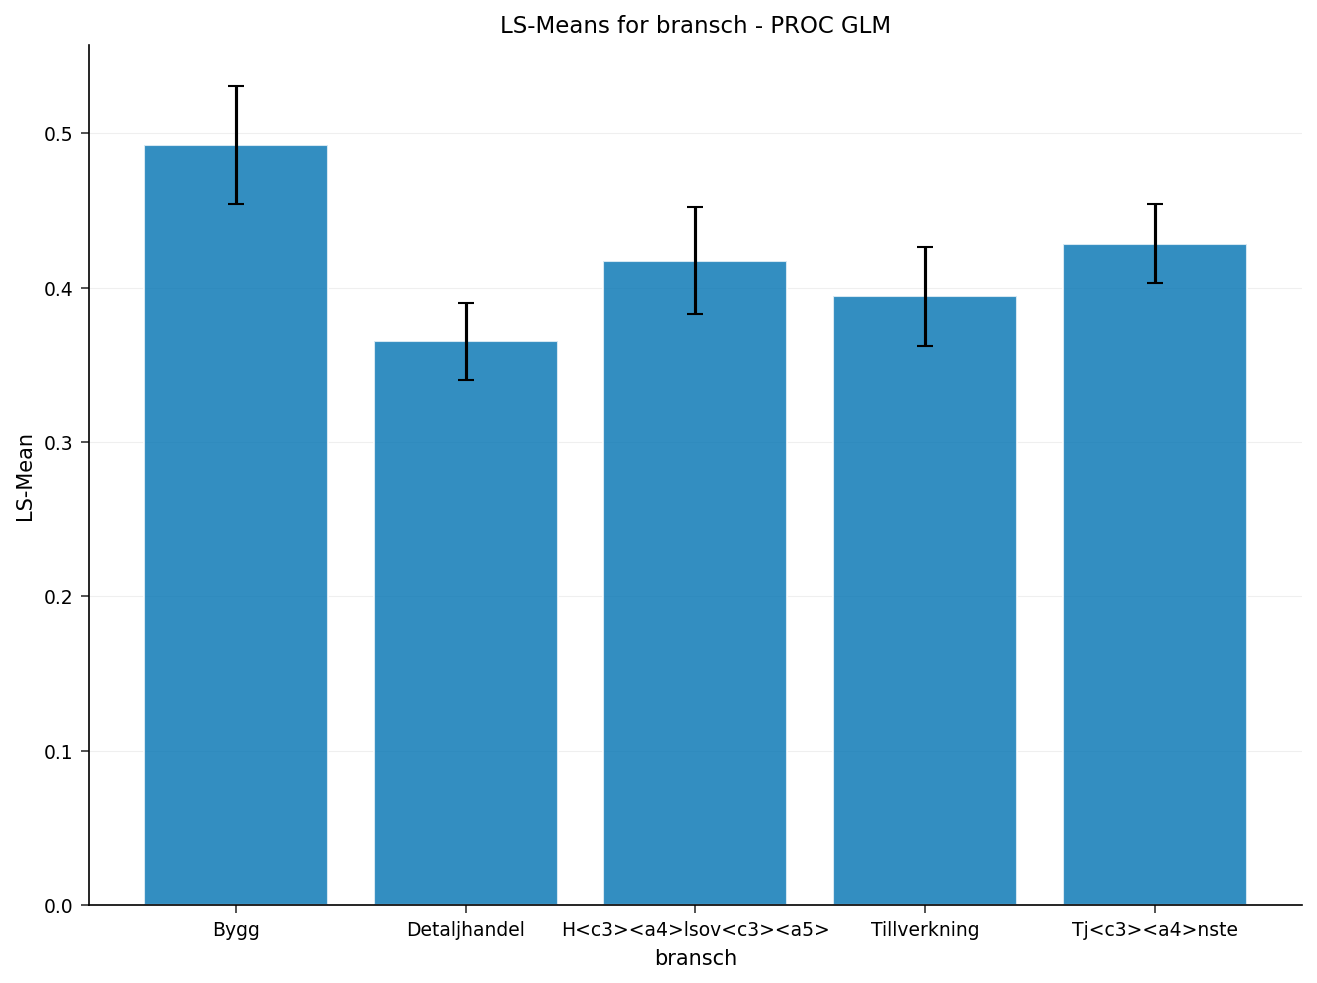

In [4]:
/* Utnyttjande efter branschsegment, justerat för drivkrafter */
PROCEDUR GLM data=kreditlinor;
    KLASS bransch;
    MODEL utnyttjandegrad =
          bransch rantetackningsgrad intaktsvolatilitet tidigare_utnyttjande
          arbetsloshet kortranta
          / SOLUTION ss3;
    LSMEANS bransch / PDIFF ADJUST=TUKEY cl;
KÖR;
QUIT;


## 5. Utnyttjandeband för stress och ekonomiskt kapital

Kapitalplaneringen behöver **svansarna** av utnyttjandefördelningen, inte bara medelvärdet. Eftersom fraktionella percentiler bäst hämtas från **PROC UNIVARIATE** snarare än PROC MEANS använder vi `PCTLPTS=` för att extrahera utnyttjandets **2,5:e och 97,5:e percentiler**. Det resulterande bandet definierar ett rimligt scenario för lågt/högt utnyttjande vid stresstestning av finansierat saldo.


In [5]:
/* Utnyttjandets 2,5:e / 97,5:e percentiler för stressband */
PROCEDUR UNIVARIATE data=kreditlinor NOPRINT;
    VARIABEL utnyttjandegrad;
    UTDATA out=utnyttjande_band
           mean=utnytt_medel
           pctlpts=2.5 97.5
           pctlpre=utnytt_p
           pctlname=lag hog;
KÖR;

PROCEDUR SKRIV data=utnyttjande_band noobs ETIKETT;
    ETIKETT utnytt_medel = "Genomsnittligt utnyttjande"
          utnytt_plag  = "2,5:e percentilen (stress låg)"
          utnytt_phog  = "97,5:e percentilen (stress hög)";
KÖR;



Genomsnittligt utnyttjande   2,5:e percentilen (stress låg)   97,5:e percentilen (stress hög)
--------------------------  -------------------------------  --------------------------------
                    0.4103                           0.1467                            0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset utnyttjande_band has 1 observations and 3 variables.
NOTE: PROC PRINT data=utnyttjande_band

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Tolkning och nästa steg

**Vad modellen visar**

- **Riskklass driver finansierad exponering.** PROC MEANS-profilen visar att det genomsnittliga utnyttjandet stiger monotont från den starkaste klassen till den svagaste — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E). Eftersom utnyttjat saldo är utnyttjandet gånger beviljad gräns omvandlar svagare klasser en större andel av sina åtaganden till finansierade saldon — den centrala insatsvaran för exponering vid fallissemang och ekonomiskt kapital för revolverande linor. (Det genomsnittliga utnyttjade saldot stiger också med klassen, med en topp vid klass D i detta urval om 100 linor; den lilla klass E-cellen på 9 linor bär en mycket stor gräns som drar upp dess medelvärde för beviljad gräns, vilket är precis den sortens smågruppsbeteende som den fullständiga boken skulle jämna ut.)
- **Låntagarens fundamenta dominerar regressionen.** I PROC REG bär **räntetäckningsgrad** den största standardiserade koefficienten (-0.45) och är skyddande — varje ytterligare enhet av täckning sänker utnyttjandet med cirka 0.11 (95 % CL -0.152 till -0.075). **Tidigare utnyttjande** är den näst starkaste drivkraften (standardiserat 0.41, skattning +0.38): linor som var starkt utnyttjade tidigare förblir högt utnyttjade. **Intäktsvolatilitet** (+0.37, p = 0.021) och makrotermerna — **arbetslöshet** (+0.036, p = 0.009) och **korträntan** (+0.036, p = 0.036) — är alla positiva och signifikanta, så en nedgång lyfter mekaniskt de portföljövergripande finansierade saldona. Alla VIF ligger under 1.17, väl under den konventionella tröskeln på 10, vilket bekräftar att drivkrafterna inte är kollineära, och CLB-intervallen utesluter noll för varje effekt utom linans mognad. Residualdiagnostiken är välartad: residualerna sprids slumpmässigt kring noll, histogrammet är ungefär normalt och Q-Q-plotten är nära linjär med endast milt svansavvikande; Cook's D flaggar fyra måttligt inflytelserika linor (över 4/n = 0.04) värda en datakvalitetsgranskning.
- **Bransch tillför en signal på gränsen.** Efter att ha kontrollerat för låntagar- och makrokovariater är den totala brancheffekten i PROC GLM endast på gränsen (Typ III F p = 0.060). Men de Tukey-justerade minsta-kvadrat-medelvärdena separerar ändå segmenten: **Bygg** har det högsta justerade utnyttjandet (0.492), följt av **Tjänster** (0.428), med **Tillverkning** (0.394), **Hälsovård** (0.374) och **Detaljhandel** (0.366) klustrade under. De parvisa testerna bekräftar att Bygg utnyttjar signifikant mer än **Detaljhandel** (skillnad 0.126, p = 0.007) och **Hälsovård** (0.118, p = 0.024); de återstående parvisa gapen är inte signifikanta. Detta är förenligt med hur rörelsekapitalintensiteten varierar per sektor och pekar ut Bygg som det segment att hålla ögonen på.

**Hur den används**

- **Prognostisera finansierade saldon** genom att tillämpa regressionen på framåtblickande makrobanor (stigande arbetslöshet, högre korträntor) för att projicera portföljens utnyttjade saldo under varje scenario.
- **Sätt stressbandet för ekonomiskt kapital** utifrån PROC UNIVARIATE-percentilerna: utnyttjandet varierar rimligen från **0.121** (2,5:e) till **0.744** (97,5:e) kring ett medelvärde på 0.404, och dimensionerar scenariot för lågt/högt utnyttjande vid en nedgång.
- **Differentiera gränser och prissättning** efter riskklass och efter Constructions förhöjda justerade utnyttjande, och ta betalt för det högre förväntade utnyttjandet — och den högre finansierade exponeringen — som MEANS- och GLM-resultaten kvantifierar.

**Utvidgningar**

Ersätt OLS-länken med en fraktionell-respons- eller betaregression (PROC GLIMMIX / PROC NLMIXED) för att respektera 0–1-gränsen, lägg till en slumpmässig låntagareffekt för flerperiodspaneler och mata det anpassade utnyttjandet direkt in i en motor för förlust vid fallissemang och ekonomiskt kapital. En omkörning på den fullständiga (obegränsade) boken skulle strama åt de små riskklass- och branschcellerna och sannolikt skärpa det gränsfallande brancheffekt-F-testet.
